## Full plot generation pass
Add you plot implementations here when they are complete so that as we update and finish the second pass new sets of plots can be immediatly generated. Comment appropriatly and describe what the plot is showing.

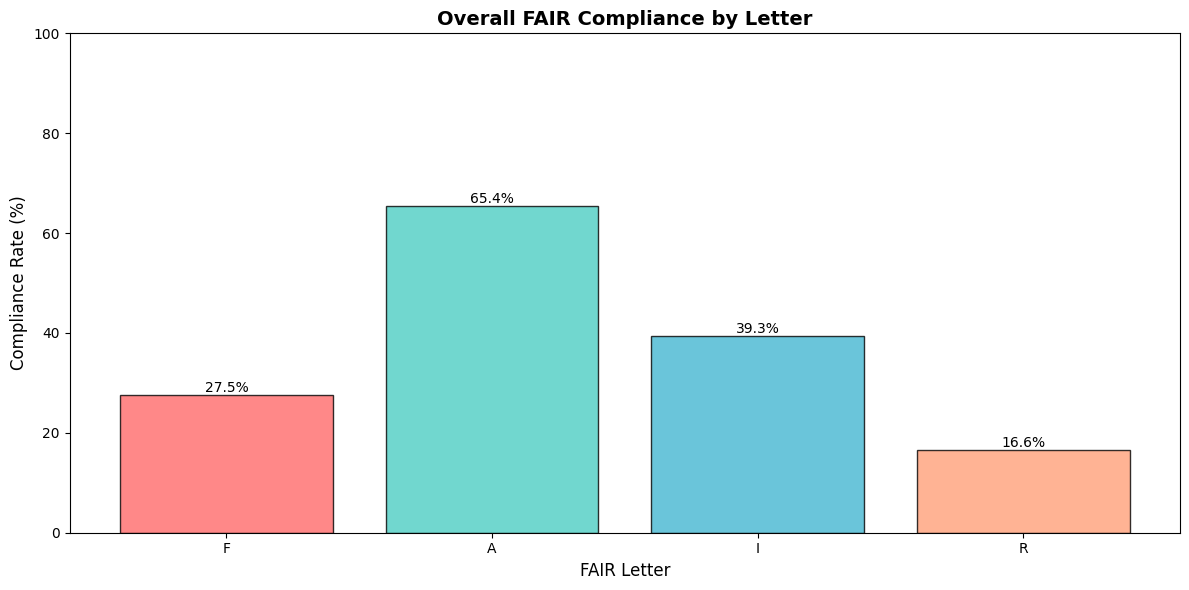

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from plotting.FAIR_compliance import (F, A, I, R, Letter_compliance,
                                      calculate_all_letter_compliance_rates,
                                      calculate_criterion_compliance_rates,
                                      calculate_full_fair_compliance,
                                      print_fair_summary)
from pre_reports.pre_process import scleaned_pandas
from plotting.repository_stats import repo_stats_main

# Load data
sample_file = "results/FAIR Evaluation Results - First Pass Responses_fixed.csv"
drop_cols = ["A1 follow-up: Which of these protocols are available to download the software?","R2 follow-up: Is there a file / project manager tool to help with the installation of other software / libraries?","Is the software itself documented well? Which of the following code readability standards have been implemented?","How long did this form take to complete?","Anything else to note?","Any additional notes for F?","Any additional notes for A?","Any additional notes for I?","Any additional notes for R?" ]
df = scleaned_pandas(sample_file, columns_to_drop=drop_cols, index_col="Paper Name:")
df = df[(df["Are any software artefacts/tools/scripts mentioned in and used in the process of gathering results for the report?"] == "Yes") ]

#Add below to the above line to exclude papers where the artefact is unavailable
#& (df["F1. Software is assigned a globally unique and persistent identifier (DOI)"] != "Artefact Unavailable")

# Plot full FAIR compliance by letter
compliance_by_letter = calculate_all_letter_compliance_rates(df)

letters = list(compliance_by_letter.keys())
rates = list(compliance_by_letter.values())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(letters, rates, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'], alpha=0.8, edgecolor='black')
ax.set_ylabel('Compliance Rate (%)', fontsize=12)
ax.set_xlabel('FAIR Letter', fontsize=12)
ax.set_title('Overall FAIR Compliance by Letter', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.style.use('ggplot')
plt.show()


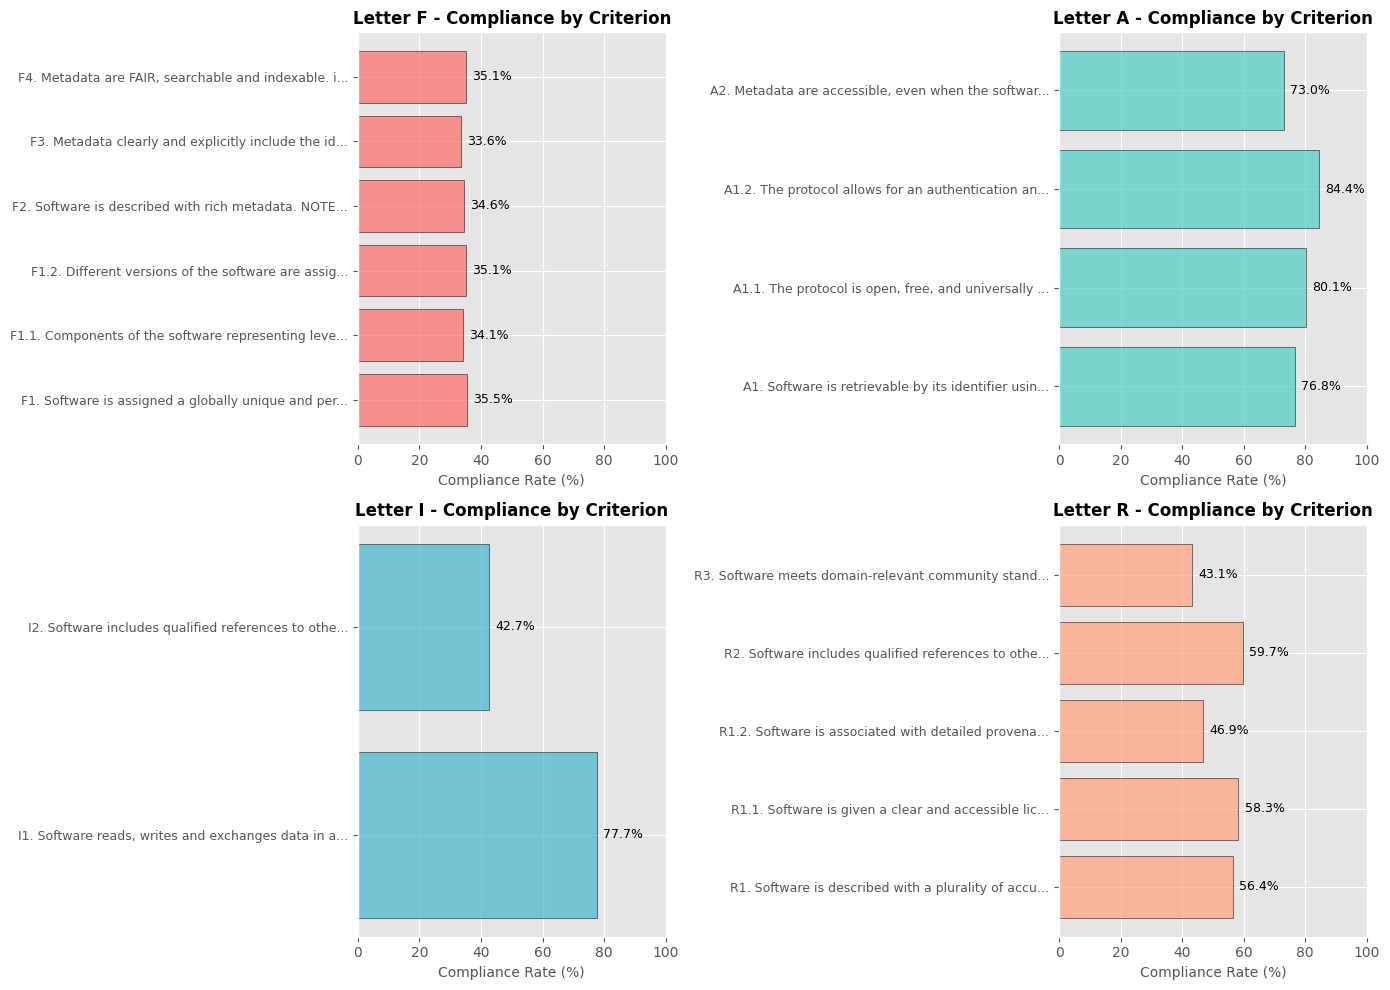

In [2]:
# Individual Letter Compliance Analysis (Using Letter_compliance)

# Create a figure with subplots for each FAIR letter
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

fair_letters = {'F': F, 'A': A, 'I': I, 'R': R}
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for idx, (letter, criteria) in enumerate(fair_letters.items()):
    # Calculate compliance for each criterion using the new function
    criterion_compliance = calculate_criterion_compliance_rates(df, criteria)
    criterion_labels = []

    for criterion in criteria:
        if criterion in df.columns:
            # Shorten label for readability
            short_label = criterion[:50] + "..." if len(criterion) > 50 else criterion
            criterion_labels.append(short_label)

    # Plot
    ax = axes[idx]
    bars = ax.barh(range(len(criterion_compliance)), criterion_compliance, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(criterion_labels)))
    ax.set_yticklabels(criterion_labels, fontsize=9)
    ax.set_xlabel('Compliance Rate (%)', fontsize=10)
    ax.set_title(f'Letter {letter} - Compliance by Criterion', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 100)

    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, criterion_compliance)):
        ax.text(value + 2, i, f'{value:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.style.use('ggplot')
plt.show()

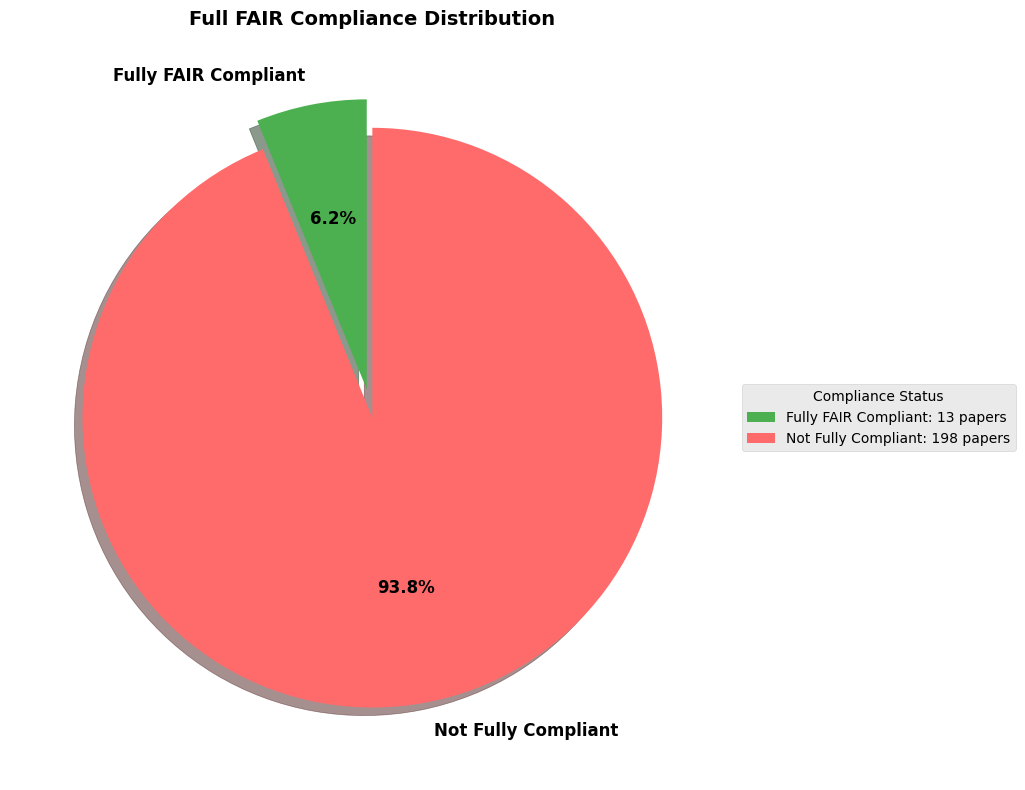

=== FAIR COMPLIANCE SUMMARY ===
Total Papers Analyzed: 211

Compliance Rates by FAIR Letter:
  F: 27.5%
  A: 65.4%
  I: 39.3%
  R: 16.6%

Full FAIR Compliance: 6.2%
  Compliant Papers: 13
  Non-Compliant Papers: 198

Fully Compliant Papers:
  ✓ WDD: Weighted Delta Debugging
  ✓ Topseed: Learning Seed Selection Strategies for Symbolic Execution from Scratch
  ✓ An Exploratory Study of ML Sketches and Visual Code Assistants
  ✓ Measuring the Runtime Performance of C++ Code Written by Humans Using Github Copilot
  ✓ Cooperative Software Verification via Dynamic Program Splitting
  ✓ On the Mistaken Assumption of Interchangeable Deep Reinforcement Learning Implementations
  ✓ Anomaly Detection in Large-Scale Cloud Systems: An Industry Case and Dataset
  ✓ GenC2Rust: Towards Generating Generic Rust Code from C
  ✓ Fairquant: Certifying and Quantifying Fairness of Deep Neural Networks
  ✓ FairSense: Long-Term Fairness Analysis of ML-Enabled Systems
  ✓ A Little Goes a Long Way: Tuning Config

In [3]:
# Full FAIR Compliance Analysis 

compliant_papers, non_compliant_papers = calculate_full_fair_compliance(df)

# Create pie chart showing full FAIR compliance
labels = ['Fully FAIR Compliant', 'Not Fully Compliant']
sizes = [len(compliant_papers), len(non_compliant_papers)]
colors = ['#4CAF50', '#FF6B6B']  # Green for compliant, red for non-compliant
explode = (0.1, 0)  # explode the compliant slice

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                  autopct='%1.1f%%', startangle=90, shadow=True)

# Style the text
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.set_title('Full FAIR Compliance Distribution\n', fontsize=14, fontweight='bold')

# Add legend with counts
ax.legend(wedges, [f'{label}: {count} papers' for label, count in zip(labels, sizes)],
          title="Compliance Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.style.use('ggplot')
plt.show()

# Print summary using the new function
print_fair_summary(df)

First pass: {'Zenodo Only': 29, 'GitHub Only': 103, 'Figshare Only': 8, 'Zenodo and GitHub': 34, 'Figshare and GitHub': 5, 'Anonymous GitHub Only': 9, 'Artefact Unavailable': 25, 'No Artefact': 29, 'Google Sites': 2, 'Other': 2}
Second pass: {'Zenodo Only': 24, 'GitHub Only': 84, 'Figshare Only': 8, 'Zenodo and GitHub': 19, 'Figshare and GitHub': 4, 'Anonymous GitHub Only': 9, 'Artefact Unavailable': 20, 'No Artefact': 12, 'Google Sites': 1, 'Other': 1}


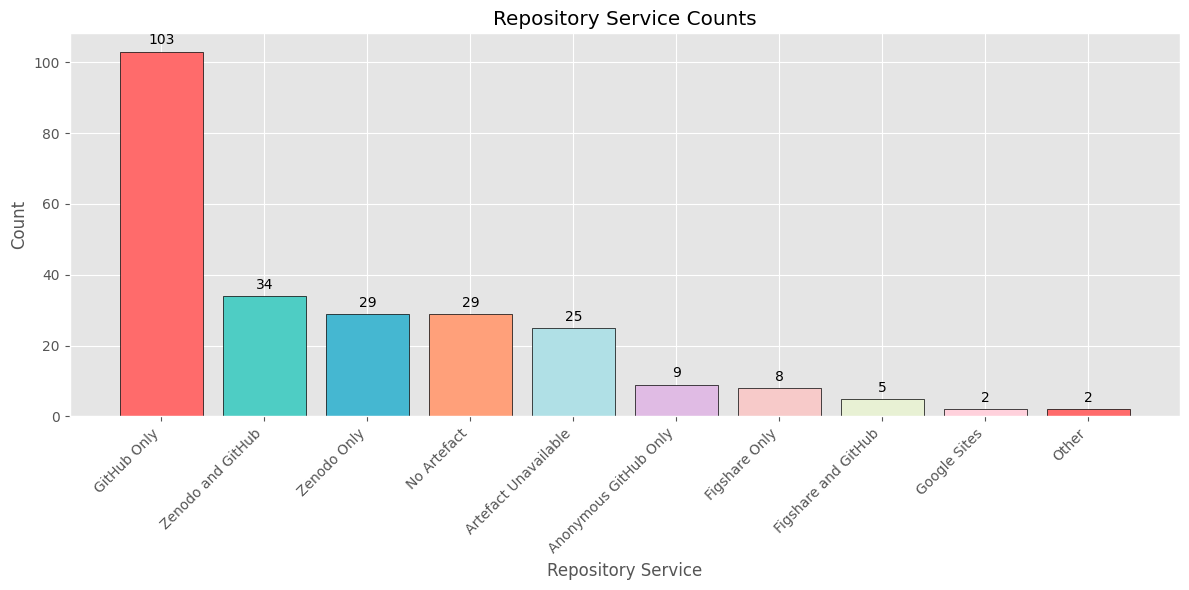

In [4]:
# Repo stats
repo_stats_main()